<a href="https://colab.research.google.com/github/SharuNivetha06/CNN_CIFAR-10/blob/main/CNN_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1863s 11us/step


In [3]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

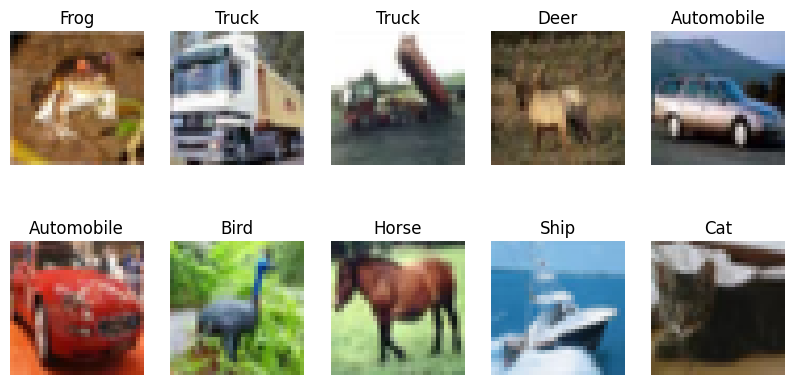

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.savefig('sample_images.eps', format='eps', dpi=600, bbox_inches='tight')
files.download('sample_images.eps')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

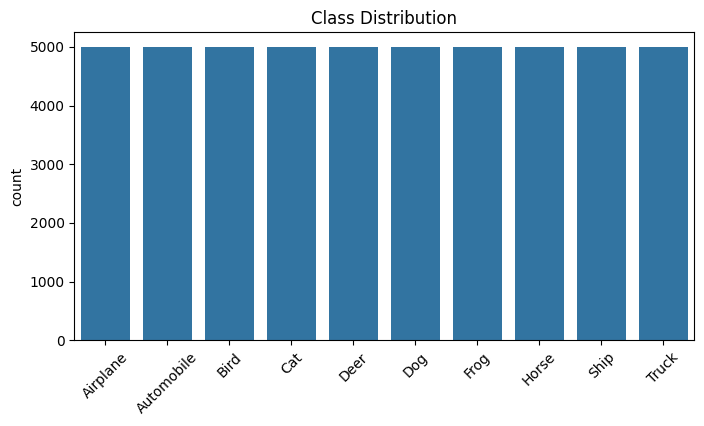

In [6]:
plt.figure(figsize=(8,4))
sns.countplot(x=y_train.flatten())
plt.xticks(range(10), class_names, rotation=45)
plt.title("Class Distribution")
plt.savefig('class_distribution.eps', format='eps', dpi=600, bbox_inches='tight')
files.download('class_distribution.eps')
plt.show()

In [7]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))

model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(units=10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(X_train,y_train_cat,validation_split=0.2,epochs=10,batch_size=64)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 90ms/step - accuracy: 0.3859 - loss: 1.6613 - val_accuracy: 0.5222 - val_loss: 1.3599
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 86ms/step - accuracy: 0.5293 - loss: 1.3236 - val_accuracy: 0.5726 - val_loss: 1.2236
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - accuracy: 0.5842 - loss: 1.1743 - val_accuracy: 0.6235 - val_loss: 1.0683
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.6245 - loss: 1.0759 - val_accuracy: 0.6313 - val_loss: 1.0268
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 88ms/step - accuracy: 0.6554 - loss: 0.9870 - val_accuracy: 0.6555 - val_loss: 0.9782
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.6823 - loss: 0.9143 - val_accuracy: 0.6809 - val_loss: 0.9226
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.7023 - loss: 0.8546 - val_accuracy: 0.6971 - val_loss: 0.8602
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.7225 - loss: 0.7935 - 

In [10]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7088 - loss: 0.8575
Test Loss: 0.8574784398078918
Test Accuracy: 0.7088000178337097


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

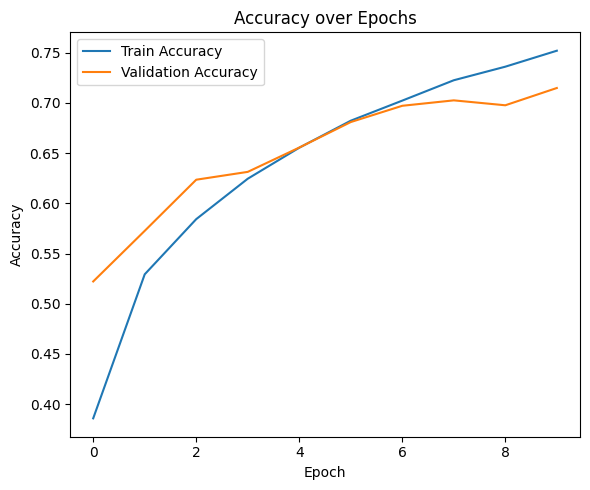

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

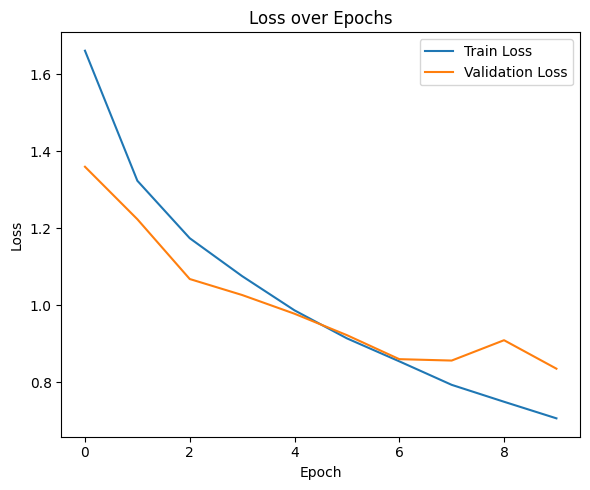

In [18]:
plt.figure(figsize=(6,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_plot.eps', format='eps', dpi=600, bbox_inches='tight')
files.download('accuracy_plot.eps')
plt.show()

plt.figure(figsize=(6,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_plot.eps', format='eps', dpi=600, bbox_inches='tight')
files.download('loss_plot.eps')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Accuracy : 0.7088
Precision: 0.7098527854268558
Recall   : 0.7088
F1 Score : 0.7052752370642248

Classification Report

              precision    recall  f1-score   support

    Airplane       0.76      0.75      0.75      1000
  Automobile       0.84      0.82      0.83      1000
        Bird       0.68      0.53      0.60      1000
         Cat       0.53      0.54      0.53      1000
        Deer       0.65      0.67      0.66      1000
         Dog       0.67      0.52      0.59      1000
        Frog       0.65      0.87      0.74      1000
       Horse       0.78      0.72      0.75      1000
        Ship       0.76      0.87      0.81      1000
       Truck       0.78      0.81      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

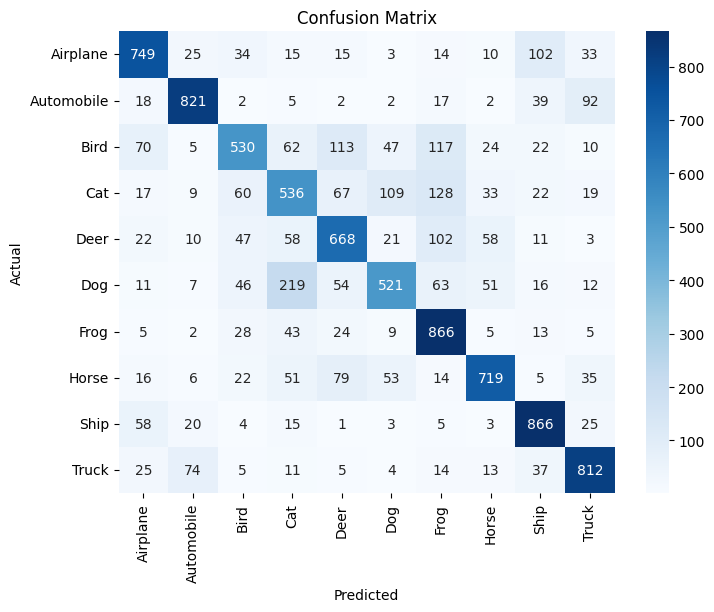

In [15]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('cm.eps', format='eps', dpi=600, bbox_inches='tight')
files.download('cm.eps')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

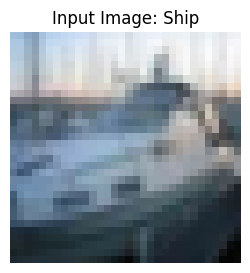

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

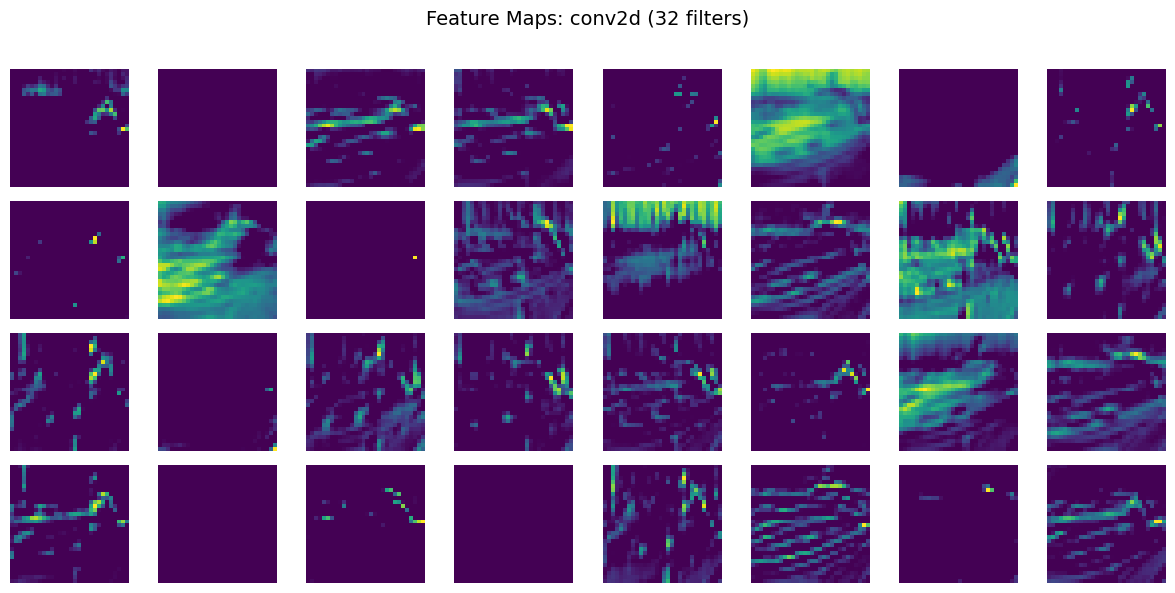

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

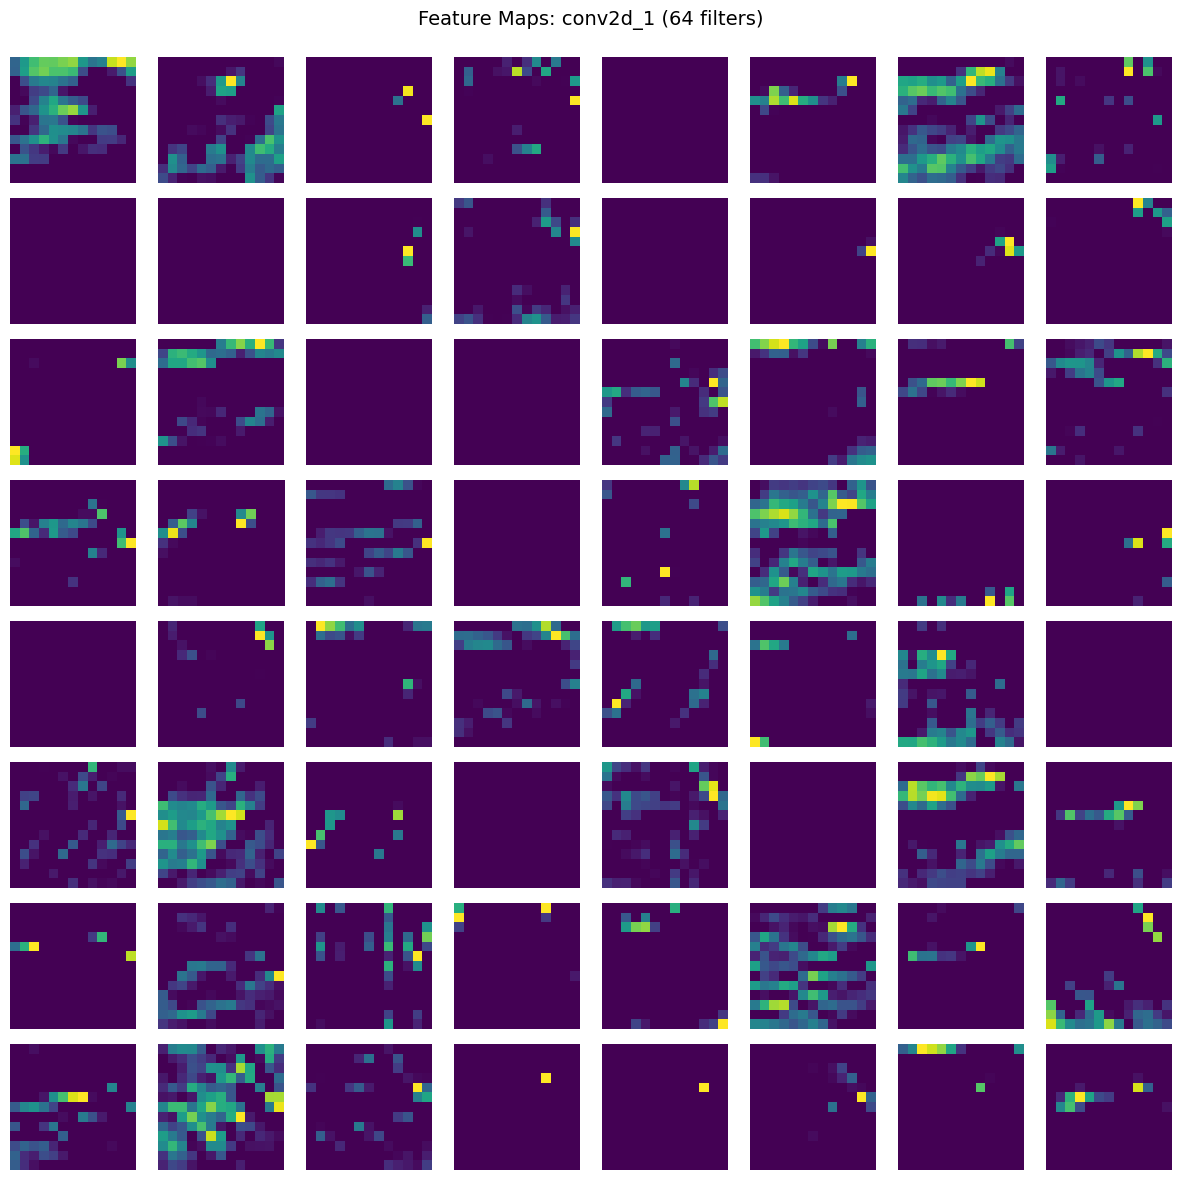

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

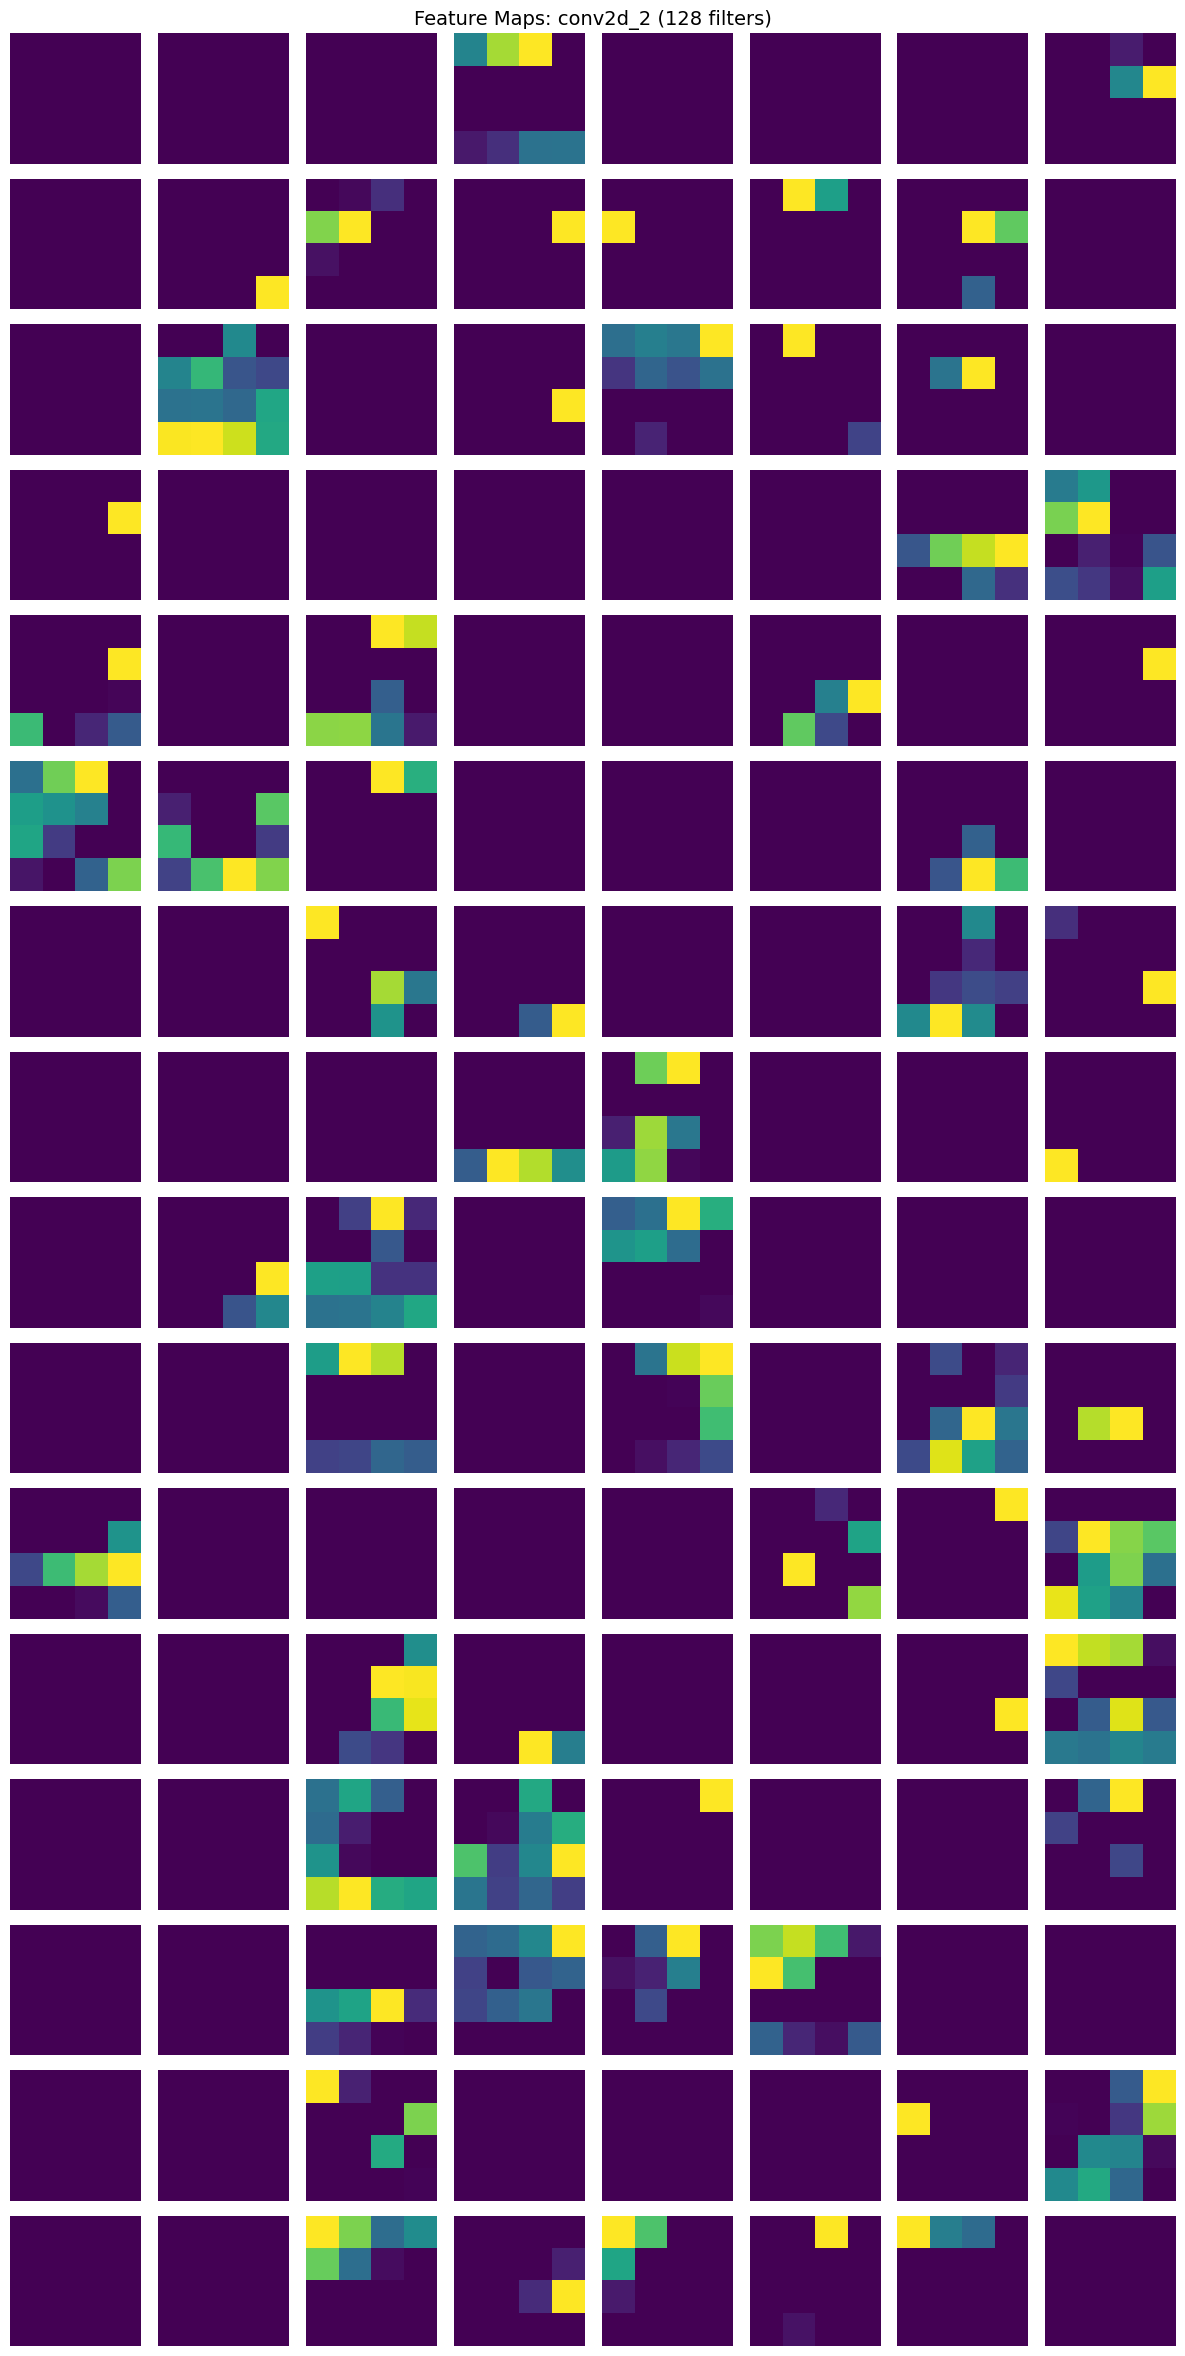

In [13]:
conv_layer_names = [layer.name for layer in model.layers if 'conv2d' in layer.name]

layer_outputs = [model.get_layer(name).output for name in conv_layer_names]
activation_model = Model(inputs=model.inputs, outputs=layer_outputs)

sample_img = X_test[2]
sample_img_batch = np.expand_dims(sample_img, axis=0)

activations = activation_model.predict(sample_img_batch)

plt.figure(figsize=(3,3))
plt.imshow(sample_img)
plt.title(f"Input Image: {class_names[y_test[2][0]]}")
plt.axis('off')
plt.savefig('image.eps', format='eps', dpi=600, bbox_inches='tight')
files.download('image.eps')
plt.show()

for layer_name, layer_activation in zip(conv_layer_names, activations):
    n_features = layer_activation.shape[-1]

    n_cols = 8
    n_rows = int(np.ceil(n_features / n_cols))

    plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5))
    plt.suptitle(f"Feature Maps: {layer_name} ({n_features} filters)\n", fontsize=14)

    for i in range(n_features):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(layer_activation[0, :, :, i], cmap='viridis')
        plt.axis('off')

    plt.savefig(f'{layer_name}_feature_maps.eps', format='eps', dpi=600, bbox_inches='tight')
    files.download(f'{layer_name}_feature_maps.eps')
    plt.tight_layout()
    plt.show()